<a href="https://colab.research.google.com/github/akshat280706/ML-Lab-Experiment/blob/main/241080009_akshat_ML_LAB6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving mushrooms.csv to mushrooms.csv


In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import(confusion_matrix, accuracy_score,
precision_score, recall_score,f1_score,roc_curve, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression



data=pd.read_csv("mushrooms.csv")
print("Dataset shape:", data.shape)

#converting categorial into numeical
X=pd.get_dummies(data.drop("class", axis=1),dtype=float)
#e=0(edible) p=1(poi)
y=data["class"].map({"e":0, "p":1}).values

X=X.values
y=y.astype(float)

#spliting
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,
                                                    random_state=42,stratify=y)
print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)

Dataset shape: (8124, 23)

Training data: (6499, 117)
Testing data: (1625, 117)



 logistic reg: 
confusion matrix: 
 [[834   8]
 [ 16 767]]
accuracy score:  0.9852307692307692
precision score:  0.9896774193548387
recall score:  0.979565772669221
F1 Score: 0.9845956354300385

library: 
Confusion Matrix: [[842   0]
 [  1 782]]
Accuracy: 0.9993846153846154
Precision: 1.0
Recall: 0.9987228607918263
F1 Score: 0.9993610223642172


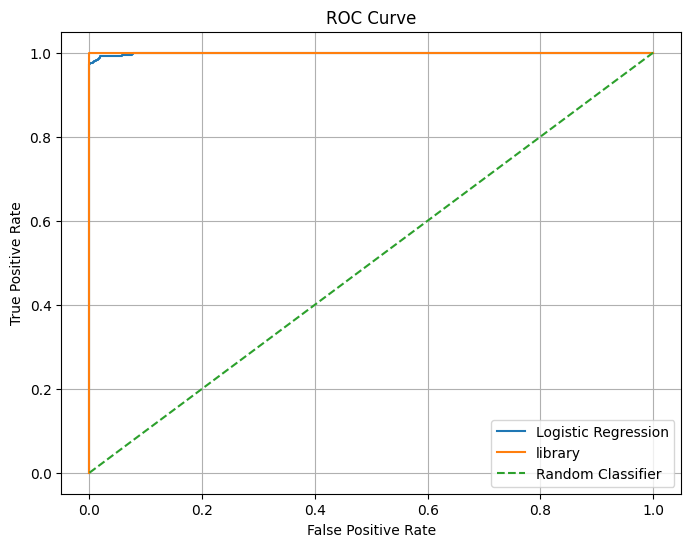

In [ ]:
#logistic regression

def sigmoid(z):
  return 1/(1+np.exp(-np.clip(z,-500,500)))
#if z smaller than -500, make it -500

def train_logistic(X,y,learning_rate=0.1,epoch=1000):
  rows,columns=X.shape
  weights=np.zeros(columns)
  bias=0

  for i in range(epoch):
    #z=Xw+b
    z=np.dot(X,weights)+bias
    #cal predictions(to conv into prob)
    predictions=sigmoid(z)
    #error
    error=predictions-y

    #gradient(how should each weight change)
    dw=np.dot(X.T, error)/rows
    #mean error
    db=np.mean(error)

    weights=weights-learning_rate*dw #gradient descent update
    bias=bias-learning_rate*db
  return weights,bias

weights,bias=train_logistic(X_train,y_train)

#predictions
def predict_probability(X,weights,bias):
  z=np.dot(X,weights)+bias
  return sigmoid(z) #converts val b/w 0 and 1

def predict(X,weights,bias):
  probabilities=predict_probability(X,weights,bias)
  return (probabilities>=0.5).astype(int) #true=1, false=0
  #>=0.5: class 1 else class 0

#predictions
y_pred=predict(X_train,weights,bias)
def predict_probability(X, weights, bias):

    z = np.dot(X, weights) + bias

    return sigmoid(z)


def predict(X, weights, bias):

    probabilities = predict_probability(X, weights, bias)

    return (probabilities >= 0.5).astype(int)


# Predictions
y_pred = predict(X_test, weights, bias)
y_prob = predict_probability(X_test, weights, bias)

print("\n logistic reg: ")
#confusion matrix
cm=confusion_matrix(y_test,y_pred)
print("confusion matrix: \n",cm)
#accuracy
acc=accuracy_score(y_test,y_pred)
print("accuracy score: ",acc)
#precision
pre=precision_score(y_test,y_pred)
print("precision score: ",pre)
#recall
rec=recall_score(y_test,y_pred)
print("recall score: ",rec)
#f1
print("F1 Score:", f1_score(y_test, y_pred))


#standard library
library_model = LogisticRegression(max_iter=1000)
library_model.fit(X_train, y_train)
library_pred = library_model.predict(X_test)
library_prob = library_model.predict_proba(X_test)[:, 1]
print("\nlibrary: ")
print("Confusion Matrix:", confusion_matrix(y_test, library_pred))
print("Accuracy:", accuracy_score(y_test, library_pred))
print("Precision:", precision_score(y_test, library_pred))
print("Recall:",recall_score(y_test, library_pred))
print("F1 Score:",f1_score(y_test, library_pred))

#roc curve
fpr_manual, tpr_manual, _ = roc_curve(y_test, y_prob)
fpr_library, tpr_library, _ = roc_curve(y_test, library_prob)
plt.figure(figsize=(8, 6))

plt.plot(fpr_manual,tpr_manual,label="Logistic Regression")
plt.plot(fpr_library,tpr_library,label="library")
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# loss=-ylog(h(x))-(1-y)log(1-h(x));
